# Tutorial for Using Split-Raster for Deep Learning

This demo we will split a large image into small tiles. It is useful for deep learning and computer vision tasks.

For example, we have a large image of size 1000-by-1000, and we want to split it into 256-by-256 tiles. The `SplitRaster` package successfully generate 16 256x256 images tiles with automatic padding on the edges. You can adjust the tile size and the overlap of the tiles for your own applications.

### Setup Environment

We recommend using `uv` to manage your environment. Run the following command in your terminal to set up the project:

```bash
uv sync
```

This demo uses Python 3.10+, but the package is compatible with Python 3.10-3.13.

In [17]:
import platform
import shutil
import sys
from pathlib import Path

print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")

BASE_DIR = Path().resolve().parent
DATA_DIR = BASE_DIR / "tests" / "data"
# print(f"Base Directory: {BASE_DIR}")
# print(f"Data Directory: {DATA_DIR}")

Python version: 3.12.13 (main, Mar 10 2026, 18:18:07) [Clang 21.1.4 ]
Platform: macOS-26.4-arm64-arm-64bit


In [18]:
import splitraster

print(f"Split-Raster version: {splitraster.__version__}")

Split-Raster version: 0.4.0


In [19]:
# Clean the output folder
shutil.rmtree(DATA_DIR / "processed" / "RGB", ignore_errors=True)
shutil.rmtree(DATA_DIR / "processed" / "GT", ignore_errors=True)

In [20]:
from splitraster import io

input_image_path = str(DATA_DIR / "raw" / "RGB.png")
gt_image_path = str(DATA_DIR / "raw" / "GT.png")

save_path = str(DATA_DIR / "processed" / "RGB")
save_path_gt = str(DATA_DIR / "processed" / "GT")

crop_size = 256
repetition_rate = 0  # Change to 0.5 for 50% overlap
overwrite = True

n = io.split_image(
    input_image_path,
    save_path,
    crop_size,
    repetition_rate=repetition_rate,
    overwrite=overwrite,
)
print(f"{n} tiles sample of RGB image are added at {save_path}")

n = io.split_image(
    gt_image_path,
    save_path_gt,
    crop_size,
    repetition_rate=repetition_rate,
    overwrite=overwrite,
)
print(f"{n} tiles sample of GT image are added at {save_path_gt}")

Input Image File Shape (H, W, D):(1000, 1000, 3)
crop_size = 256, stride = 256
Padding Image File Shape (H, W, D):(1024, 1024, 3)


Generating: 100%|██████████| 16/16 [00:00<00:00, 210.22img/s]


16 tiles sample of RGB image are added at /Users/caihaocui/GitHub/split_raster/tests/data/processed/RGB
Input Image File Shape (H, W, D):(1000, 1000)
crop_size = 256, stride = 256
Padding Image File Shape (H, W, D):(1024, 1024)


Generating: 100%|██████████| 16/16 [00:00<00:00, 1142.61img/s]

16 tiles sample of GT image are added at /Users/caihaocui/GitHub/split_raster/tests/data/processed/GT


## Random Sampling Code

Use the random sampling code to generate a fixed number of tiles. This is useful for early stage exploration.

In [21]:
# Clean the output folder
shutil.rmtree(DATA_DIR / "processed" / "Rand" / "RGB", ignore_errors=True)
shutil.rmtree(DATA_DIR / "processed" / "Rand" / "GT", ignore_errors=True)

In [22]:
input_save_path = str(DATA_DIR / "processed" / "Rand" / "RGB")
gt_save_path = str(DATA_DIR / "processed" / "Rand" / "GT")

n = io.random_crop_image(
    input_image_path,
    input_save_path,
    gt_image_path,
    gt_save_path,
    crop_size=256,
    crop_number=20,
    img_ext=".png",
    label_ext=".png",
    overwrite=True,
)

print(f"{n} sample pairs are added at {input_save_path} and {gt_save_path}.")

Generating: 100%|██████████| 20/20 [00:00<00:00, 183.25img/s]

20 sample pairs are added at /Users/caihaocui/GitHub/split_raster/tests/data/processed/Rand/RGB and /Users/caihaocui/GitHub/split_raster/tests/data/processed/Rand/GT.


## Visualizing the Output

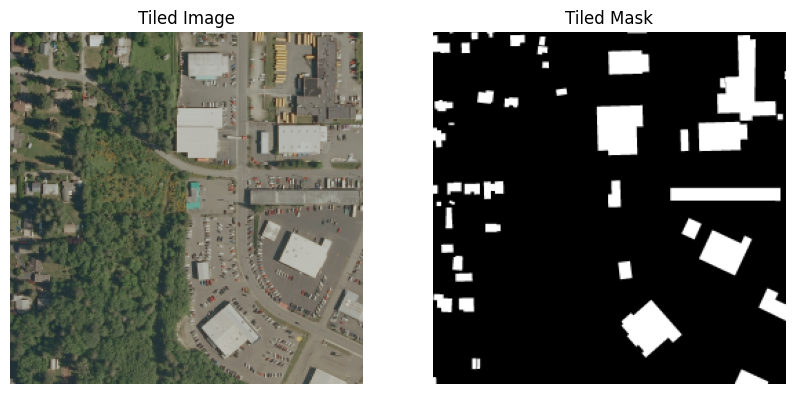

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread


def plot_pair(img_path, mask_path, title="Sample"):
    img = imread(img_path)
    mask = imread(mask_path)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img)
    ax[0].set_title(f"{title} Image")
    ax[0].axis("off")

    ax[1].imshow(mask, cmap="gray")
    ax[1].set_title(f"{title} Mask")
    ax[1].axis("off")
    plt.show()


sample_idx = "0001.png"
plot_pair(Path(save_path) / sample_idx, Path(save_path_gt) / sample_idx, title="Tiled")

## Use the output as input of a PyTorch Model

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset


class DatasetSegmentation(Dataset):
    def __init__(self, image_path, label_path):
        self.img_folder = Path(image_path)
        self.mask_folder = Path(label_path)
        self.imgs = sorted([f.name for f in self.img_folder.iterdir() if f.suffix == ".png"])
        self.masks = sorted([f.name for f in self.mask_folder.iterdir() if f.suffix == ".png"])

    def __getitem__(self, idx):
        img_p = str(self.img_folder / self.imgs[idx])
        mask_p = str(self.mask_folder / self.masks[idx])

        data = imread(img_p)
        data = np.moveaxis(data, -1, 0)  # HWC to CHW
        label = imread(mask_p)
        label = label / 255
        return torch.from_numpy(data).float(), torch.from_numpy(label).long()

    def __len__(self):
        return len(self.imgs)


dataset = DatasetSegmentation(save_path, save_path_gt)
loader = DataLoader(
    dataset, batch_size=16, shuffle=False
)  # For better visualization, set shuffle=False; In training, you may want to set shuffle=True.

features, labels = next(iter(loader))
print(f"Feature batch shape: {features.size()}")
print(f"Labels batch shape: {labels.size()}")

Feature batch shape: torch.Size([16, 3, 256, 256])
Labels batch shape: torch.Size([16, 256, 256])


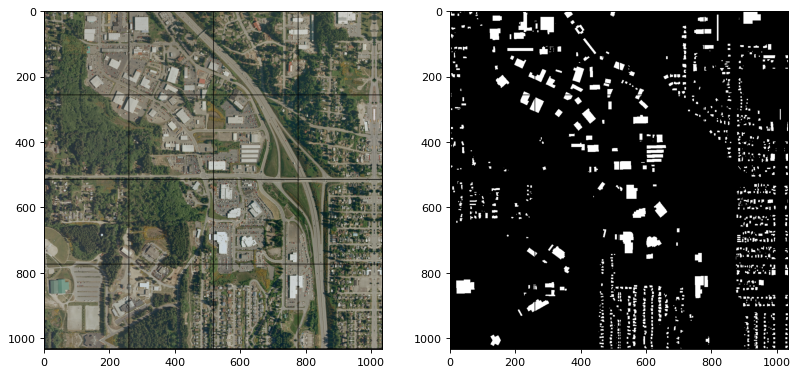

In [25]:
grid_img = torchvision.utils.make_grid(features / 255, nrow=4)
grid_label = torchvision.utils.make_grid(labels.unsqueeze_(1), nrow=4)
plt.figure(figsize=(12, 18), dpi=80)
plt.subplot(1, 2, 1)
plt.imshow(grid_img.permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(grid_label[0, :, :], cmap="gray")
plt.show()

In [26]:
from datetime import datetime

print(f"Latest run time {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Latest run time 2026-03-29 12:07:21
